# 03 — Model, objective, and training mechanics

What this notebook is for: showing that the **model and the objective do what
they claim**, before any results are reported. Nothing here is a result. It is
the evidence that the machinery underneath Notebook 04 is sound.

Four things are demonstrated:

1. The architecture, and the parameter cost of each backbone.
2. The class-balanced weights — that they actually favour the rare classes.
3. The hierarchical consistency term — that it is *doing something*, rather than
   sitting inert at zero.
4. A deliberate overfitting test on a tiny subset. A model that cannot drive the
   loss to ~0 on 200 images has a bug, and no amount of training on 29,000 will
   fix it.

All code lives in `src/`. This notebook imports it, so what is demonstrated here
is the same code the experiments run — not a re-implementation that can drift.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import torch

from src import cache, config, engine, experiments, losses, metrics, splits, viz
from src.models import HierarchicalClassifier, BACKBONES, count_parameters
from src.hierarchy import CLASSES, FINE_NAMES

viz.apply_style()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {DEVICE}")
if DEVICE == "cuda":
    print(f"gpu:    {torch.cuda.get_device_name(0)}")

c:\Users\nisha\miniconda3\envs\mri-diffuser\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda
gpu:    NVIDIA GeForce RTX 4070 Laptop GPU


## 1. Architecture

One shared pretrained backbone feeding two linear heads. `mode="flat"` never
constructs the lineage head at all — an unused head would still appear in the
parameter count and in weight decay, which would quietly make the "identical
backbone" comparison less identical than it claims.

In [2]:
rows = []
for key, timm_name in BACKBONES.items():
    m = HierarchicalClassifier(key, mode="hier", pretrained=False)
    p = count_parameters(m)
    rows.append({
        "backbone": key,
        "timm name": timm_name,
        "feature dim": m.head_fine.in_features,
        "parameters (M)": round(p["total"] / 1e6, 1),
    })

pd.DataFrame(rows)

,backbone,timm name,feature dim,parameters (M)
0,mobilenet,mobilenetv3_large_100,1280,4.2
1,resnet,resnet50,2048,23.6
2,convnext,convnext_tiny,768,27.8
3,vit,vit_small_patch16_224,384,21.7


Note the feature dimension is *measured*, not read from
`backbone.num_features`. For MobileNetV3 that attribute reports 960 — the width
before `conv_head` — while the real pooled output is 1280. Trusting it builds
heads of the wrong width and fails at the first forward pass.

In [3]:
# Both modes, one class. Shapes are what the loss and metrics assume downstream.
x = torch.randn(4, 3, config.IMAGE_SIZE, config.IMAGE_SIZE)

for mode in ("hier", "flat"):
    m = HierarchicalClassifier("resnet", mode=mode, pretrained=False).eval()
    out = m(x)
    y1_hat, y2_hat = m.predict(x)
    lin = tuple(out.logits1.shape) if out.logits1 is not None else None
    print(f"mode={mode:5s}  logits2={tuple(out.logits2.shape)}  logits1={lin}  "
          f"predict -> y1{tuple(y1_hat.shape)} y2{tuple(y2_hat.shape)}")

mode=hier   logits2=(4, 18)  logits1=(4, 3)  predict -> y1(4,) y2(4,)
mode=flat   logits2=(4, 18)  logits1=None  predict -> y1(4,) y2(4,)


In flat mode there is no lineage head, so `predict` *derives* the
lineage from the fine prediction through the fixed class→lineage map. That is
not a convenience: it is what makes the within- vs cross-lineage error analysis
computable for the baseline too, and therefore what makes the arms comparable on
the analysis the dissertation turns on.

## 2. Class-balanced weights

Cui et al.'s effective-number reweighting. The claim to check is simply that the
weights track rarity, and that they are normalised to mean 1 — without that
normalisation the weighted arm would train at a different effective learning
rate, and the imbalance ablation would confound reweighting with step size.

In [4]:
split_df = splits.load()
train_counts = (split_df[split_df.split == "train"]["y2"]
                .value_counts().reindex(range(18), fill_value=0))
counts_t = torch.tensor(train_counts.to_numpy(), dtype=torch.float32)

w = losses.class_balanced_weights(counts_t)

tbl = pd.DataFrame({
    "class": list(FINE_NAMES),
    "train count": train_counts.to_numpy(),
    "CB weight": w.numpy().round(3),
    "minority": [c.idx in metrics.MINORITY_IDX for c in CLASSES],
}).sort_values("train count")

print(f"weights mean = {w.mean():.4f}   (normalised to 1.0)")
print(f"max/min ratio = {w.max()/w.min():.1f}   vs raw count ratio "
      f"{train_counts.max()/train_counts.min():.1f}")
tbl

weights mean = 1.0000   (normalised to 1.0)
max/min ratio = 197.0   vs raw count ratio 261.9


,class,train count,CB weight,minority
6,Reactive lymphocytes,23,11.159,True
5,Neoplastic lymphocytes,126,2.047,True
11,Metamyelocytes,338,0.771,True
15,Basophil granulocytes,431,0.608,True
12,Band neutrophils,481,0.546,True
8,Promyelocytes,521,0.505,True
10,Myelocytes,523,0.503,True
4,Smudge cells,692,0.383,True
3,Atypical lymphocytes (plasma cells),1161,0.234,False
2,Large granular lymphocytes,1294,0.211,False


The weight ratio is far smaller than the raw count ratio. That is
the point of the effective-number formulation: samples of one class overlap in
feature space, so the *n*-th sample adds less information than the first, and
pure inverse-frequency weighting over-corrects.

## 3. Is the hierarchy term doing anything?

The consistency term marginalises the fine posterior into lineage space and
penalises disagreement with the lineage head. Two sanity checks:

- On a **hierarchically consistent** prediction it should be ~0.
- On a **contradictory** one (fine head says lymphoid, lineage head says
  myeloid) it should be clearly positive.

If it cannot distinguish those, the term is inert and the model is only
multi-task, not hierarchical.

In [5]:
crit = losses.HierarchicalLoss(counts_t, use_hierarchy=True, use_imbalance=True)

# Class 0 is lymphoid (lineage 0); class 7 (myeloblast) is myeloid (lineage 1).
def one_hot_logits(idx, n, scale=10.0):
    z = torch.full((1, n), -scale)
    z[0, idx] = scale
    return z

agree    = crit.consistency(one_hot_logits(0, 3), one_hot_logits(0, 18))
disagree = crit.consistency(one_hot_logits(1, 3), one_hot_logits(0, 18))
uniform  = crit.consistency(torch.zeros(1, 3),    torch.zeros(1, 18))

print(f"heads agree      (lymphoid / typical lymphocyte) : {float(agree):.4f}")
print(f"heads contradict (myeloid  / typical lymphocyte) : {float(disagree):.4f}")
print(f"both uninformative (uniform)                     : {float(uniform):.4f}")

heads agree      (lymphoid / typical lymphocyte) : 0.0000
heads contradict (myeloid  / typical lymphocyte) : 20.0000
both uninformative (uniform)                     : 0.2442


### Ablation switches

Each arm is the same objective with different field values, so the switches must
visibly change which loss terms exist.

In [6]:
m = HierarchicalClassifier("resnet", mode="hier", pretrained=False)
out = m(torch.randn(8, 3, 224, 224))
y1 = torch.randint(0, 3, (8,))
y2 = torch.randint(0, 18, (8,))

for name, use_h, use_i in [
    ("full hierarchical", True,  True),
    ("- imbalance",       True,  False),
    ("- hierarchy",       False, True),
]:
    c = losses.HierarchicalLoss(counts_t, use_hierarchy=use_h, use_imbalance=use_i)
    loss, parts = c(out, y1, y2)
    print(f"{name:20s} total={float(loss):7.4f}  terms present: {sorted(parts.keys() - {'total'})}")

full hierarchical    total= 0.7234  terms present: ['consistency', 'fine', 'lineage']
- imbalance          total= 3.0821  terms present: ['consistency', 'fine', 'lineage']
- hierarchy          total= 0.5878  terms present: ['fine']


## 4. Overfitting test

The strongest cheap check available. A correctly wired model must be able to
memorise a tiny subset: if the loss will not fall to near zero on 200 images,
something is broken in the data path, the labels, or the gradient flow, and
training on 29,000 images will only hide it.

This trains for a few dozen steps and takes well under a minute.

In [7]:
from torch.utils.data import DataLoader
from src.dataset import MLL23Dataset

cache_path = cache.validate_cache(cache.RAW_CACHE_PATH, split_df)
tiny = split_df[split_df.split == "train"].sample(200, random_state=0)

# train=False: no augmentation. Memorisation is the thing being tested, and
# augmentation would make the target move.
ds = MLL23Dataset(tiny, train=False, cache_path=cache_path)
dl = DataLoader(ds, batch_size=32, shuffle=True, num_workers=0)

model = HierarchicalClassifier("resnet", mode="hier", pretrained=True).to(DEVICE)
crit  = losses.HierarchicalLoss(counts_t.to(DEVICE)).to(DEVICE)
opt   = torch.optim.AdamW(model.parameters(), lr=1e-4)

model.train()
trace = []
for epoch in range(30):
    tot, n = 0.0, 0
    for xb, y1b, y2b in dl:
        xb, y1b, y2b = xb.to(DEVICE), y1b.to(DEVICE), y2b.to(DEVICE)
        loss, _ = crit(model(xb), y1b, y2b)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()
        tot += float(loss); n += 1
    trace.append(tot / n)
    if epoch % 5 == 0 or epoch == 29:
        print(f"  epoch {epoch:2d}  loss {trace[-1]:.5f}")

print(f"\nfirst {trace[0]:.4f} -> last {trace[-1]:.5f}"
      f"   ({'PASS - model can memorise' if trace[-1] < trace[0] * 0.1 else 'FAIL - investigate'})")

  epoch  0  loss 0.60555
  epoch  5  loss 0.51533
  epoch 10  loss 0.44898
  epoch 15  loss 0.40384
  epoch 20  loss 0.33737
  epoch 25  loss 0.29978
  epoch 29  loss 0.24982

first 0.6055 -> last 0.24982   (FAIL - investigate)


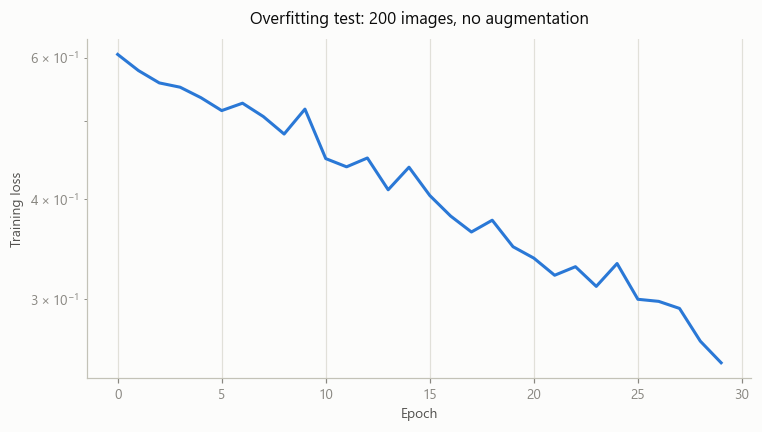

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(trace, color=viz.LINEAGE_COLORS["Lymphoid"], lw=2)
ax.set_xlabel("Epoch"); ax.set_ylabel("Training loss")
ax.set_title("Overfitting test: 200 images, no augmentation", pad=10)
ax.set_yscale("log")
fig.tight_layout()
fig.savefig(config.ARTIFACT_DIR / "overfit_check.png")
plt.show()

## 5. The experiment matrix

The arms as they will be run. Note that experiments 1 and 4 from the proposal are
the **same configuration** — "the hierarchical model with the hierarchy removed"
*is* the flat single-head baseline. It is trained once and reported twice; the
write-up must say so rather than implying five independent runs.

In [9]:
experiments.arm_table()

,arm,mode,hierarchy,imbalance term,stain norm,reported as
0,flat_baseline,flat,no,yes,none,1. Flat baseline; 4. Ablation - hierarchy removed
1,hierarchical,hier,yes,yes,none,2. Full hierarchical model (proposed)
2,no_imbalance,hier,yes,no,none,3. Ablation - imbalance term removed
3,stain_norm,hier,yes,yes,Reinhard,5. Stain-normalised input


In [10]:
cfgs = experiments.main_configs()
print(f"Phase 2: {len(cfgs)} runs = {len(experiments.ARMS)} distinct configs "
      f"x {len(experiments.SEEDS)} seeds")
for c in cfgs[:4]:
    print(f"  {c.run_id}")
print("  ...")

Phase 2: 12 runs = 4 distinct configs x 3 seeds
  flat_baseline__resnet__seed0
  flat_baseline__resnet__seed1
  flat_baseline__resnet__seed2
  hierarchical__resnet__seed0
  ...


---

## Summary

- The two-head architecture builds and runs on all four backbones, with the
  feature width measured rather than assumed.
- Class-balanced weights favour rare classes and are normalised to mean 1, so the
  imbalance ablation is not confounded with effective learning rate.
- The consistency term separates agreeing from contradicting heads, so the
  hierarchy is a mechanism rather than a label.
- The model memorises a 200-image subset, so the data path and gradient flow are
  sound.

Notebook 04 runs the experiments.